# EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering
 September 2, 2026

**Name:** Induwara M.L.A.S. &nbsp;&middot;&nbsp; **Index No.:** 230261F

In [10]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "gray"

---
## Question 1

Implement the intensity transformation depicted in Fig. 1a on the image shown in Fig. 1b
by writing a function `intensity_transform(im, breakpoints)` where the break points are, e.g.,

$$
\begin{bmatrix}
0 & 0\\
50 & 50\\
100 & 150\\
150 & 255\\
255 & 255
\end{bmatrix}.
$$

Experiment with different break points to get a visually pleasing output. Show the intensity
transformation as a plot and the original and transformed images side-by-side.


<table><tr><td><figure>
<img src="figures/fig1a.png" width="330">
<figcaption><em>(a) Intensity transformation.</em></figcaption>
</figure></td><td><figure>
<img src="figures/fig1b.png" width="260">
<figcaption><em>(b) Image for intensity transformation.</em></figcaption>
</figure></td></tr></table>

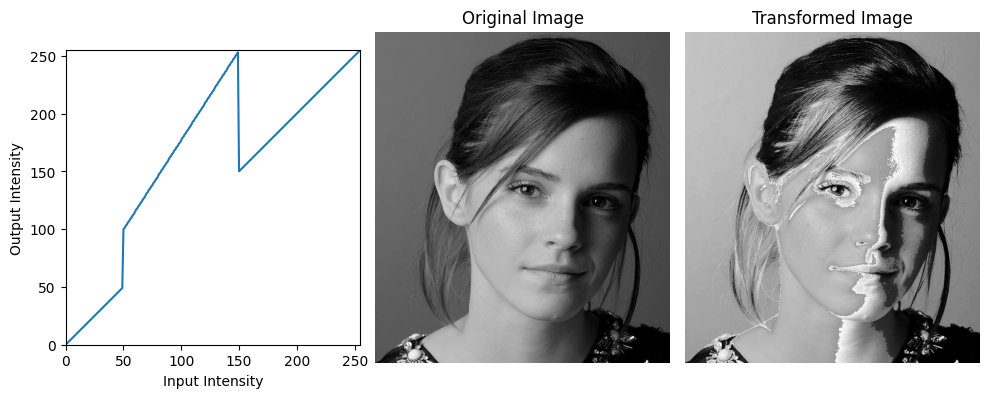

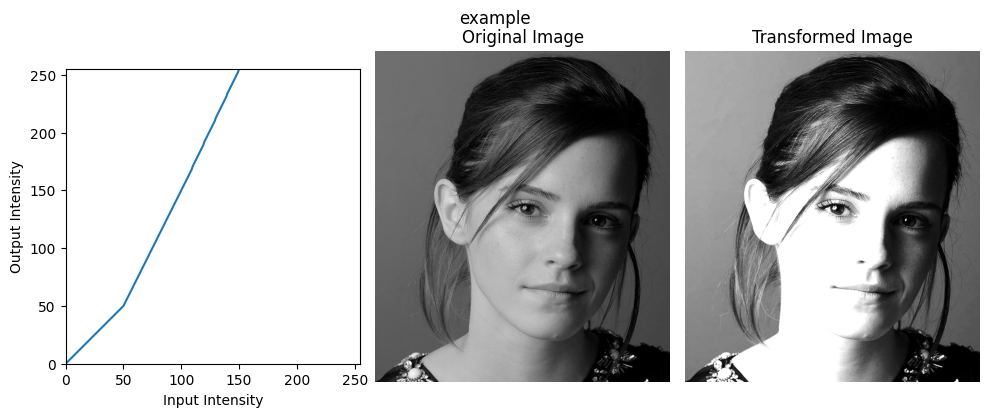

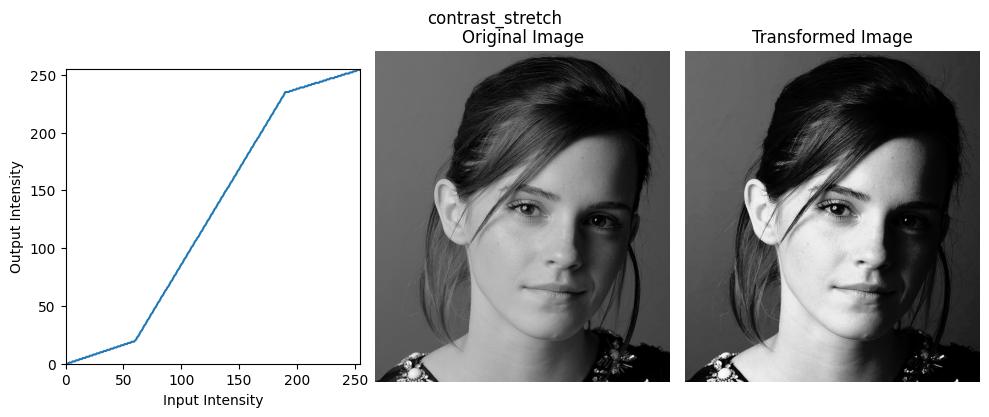

In [11]:
bp = np.array([[0,0], [50,50], [50,100], [150, 255], [150, 150], [255,255]])

def create_lut(bp):
    """
    Create a lookup table for a piecewise linear transformation defined by breakpoints bp.
    """
    c = np.asarray(bp, dtype=float)
    assert c[0,0]==0 and c[-1,0]==255, "Breakpoints must start at 0 and end at 255"

    t = np.zeros(256, dtype=np.uint8)

    for (x0, y0), (x1, y1) in zip(c[:-1], c[1:]):
        x0, y0, x1, y1 = map(int, (x0, y0, x1, y1))
        if x1 == x0:
            t[x0] = y1
            continue
        t[x0:x1+1] = np.linspace(y0, y1, x1-x0+1)

    return np.round(t).clip(0,255).astype(np.uint8)
    
def intensity_transform(img, t):
    """
    Apply a piecewise linear intensity transformation to an image using breakpoints bp.
    """
    lut = create_lut(bp)
    return cv.LUT(img, lut)


img = cv.imread("figures/fig1b.png", cv.IMREAD_GRAYSCALE)
t = create_lut(bp)
out = intensity_transform(img, t)

def img_draw(img, out, t):
    fig, axes = plt.subplots(1, 3)
    axes[0].plot(t)
    axes[0].set_xlabel("Input Intensity")
    axes[0].set_ylabel("Output Intensity")
    axes[0].set_xlim(0, 255)
    axes[0].set_ylim(0, 255)
    axes[0].set_aspect("equal")

    axes[1].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Original Image")
    axes[1].axis("off")

    axes[2].imshow(out, cmap="gray", vmin=0, vmax=255)
    axes[2].set_title("Transformed Image")
    axes[2].axis("off")

def img_show():
    plt.tight_layout()
    plt.show()

img_draw(img, out, t)
img_show()

exp = {
    "example": [[0,0], [50,50], [100,150], [150,255], [255,255]],
    "contrast_stretch": [[0,0], [60,20], [190,235], [255,255]],
}

for j, (name, bp) in enumerate(exp.items()):
    t = create_lut(bp)
    out = intensity_transform(img, t)
    img_draw(img, out, t)
    plt.suptitle(name)
    img_show()



---
## Question 2

Apply a similar operation as above (question 1) to accentuate

&nbsp;&nbsp;(a) white matter

&nbsp;&nbsp;(b) gray matter

in the brain proton density image shown in Fig. 2. Show the intensity transformations as a plots.


<figure>
<img src="figures/fig2.png" width="260">
<figcaption><em>Figure 2: A brain proton density slice.</em></figcaption>
</figure>

peaks: [7, 168, 195, 228]
valley 7-168: 134
valley 168-195: 184
valley 195-228: 221
low edge: 150


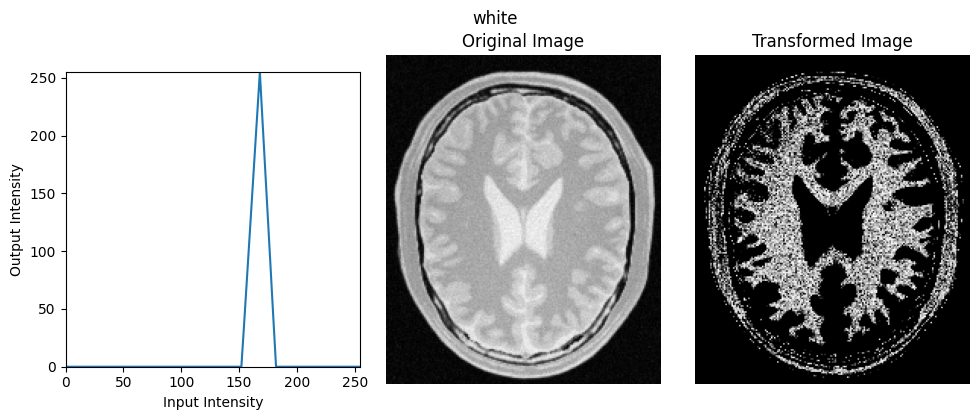

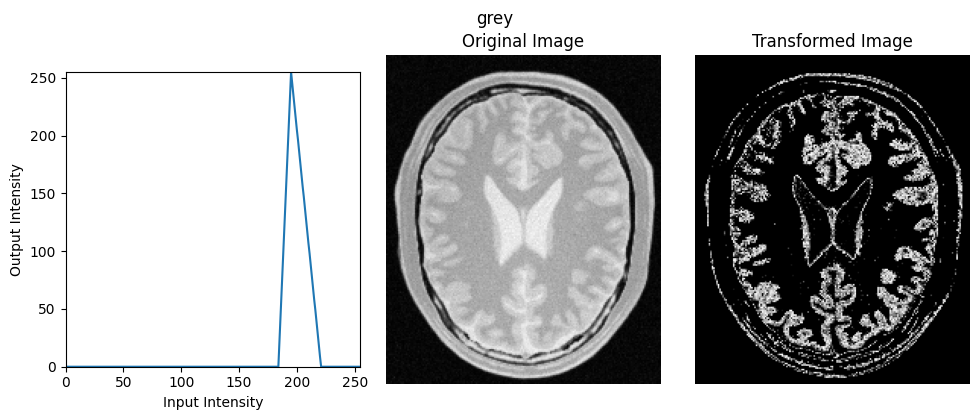

In [12]:
img = cv.imread("figures/fig2.png", cv.IMREAD_GRAYSCALE)

h  = np.bincount(img.ravel(), minlength=256).astype(float)
hs = np.convolve(h, np.ones(9)/9, mode='same')
# modes
peaks = [i for i in range(6, 250)
         if hs[i] == hs[i-6:i+7].max() and hs[i] > 0.002*img.size]
print('peaks:', peaks)                                   # 7, 168, 195, 228

# valleys between consecutive modes -> class boundaries
for a, b in zip(peaks[:-1], peaks[1:]):
    print(f'valley {a}-{b}: {a + int(np.argmin(hs[a:b+1]))}')   # 184, 221

# low edge of the darker mode: 20% of peak height
p = 168
lo = p
while lo > 20 and hs[lo] > 0.20*hs[p]:
    lo -= 1
print('low edge:', lo)


def band_breakpoints(lo, peak, hi, floor=0, ceil=255):
    return [[0, floor], [lo, floor], [peak, ceil], [hi, floor], [255, floor]]

bp_a = band_breakpoints(152, 168, 182)   # mode at 168
bp_b = band_breakpoints(182, 196, 213)   # mode at 195


transforms = {
    "white": band_breakpoints(152, 168, 182),
    "grey": band_breakpoints(184, 195, 221),
}

for j, (name, bp) in enumerate(transforms.items()):
    t = create_lut(bp)
    out = intensity_transform(img, t)
    img_draw(img, out, t)
    plt.suptitle(name)
    img_show()

---
## Question 3

Consider the image shown in Fig. 3.<sup>1</sup>

&nbsp;&nbsp;(a) Apply gamma correction to the $L$ plane in the $L^*a^*b^*$ color space and state the $\gamma$ value.

&nbsp;&nbsp;(b) Show the histograms of the original and corrected images.

<sub><sup>1</sup> https://www.adobe.com/creativecloud/photography/discover/highlights-and-shadows.html</sub>


<figure>
<img src="figures/fig3.png" width="300">
<figcaption><em>Figure 3: Image for gamma correction.</em></figcaption>
</figure>

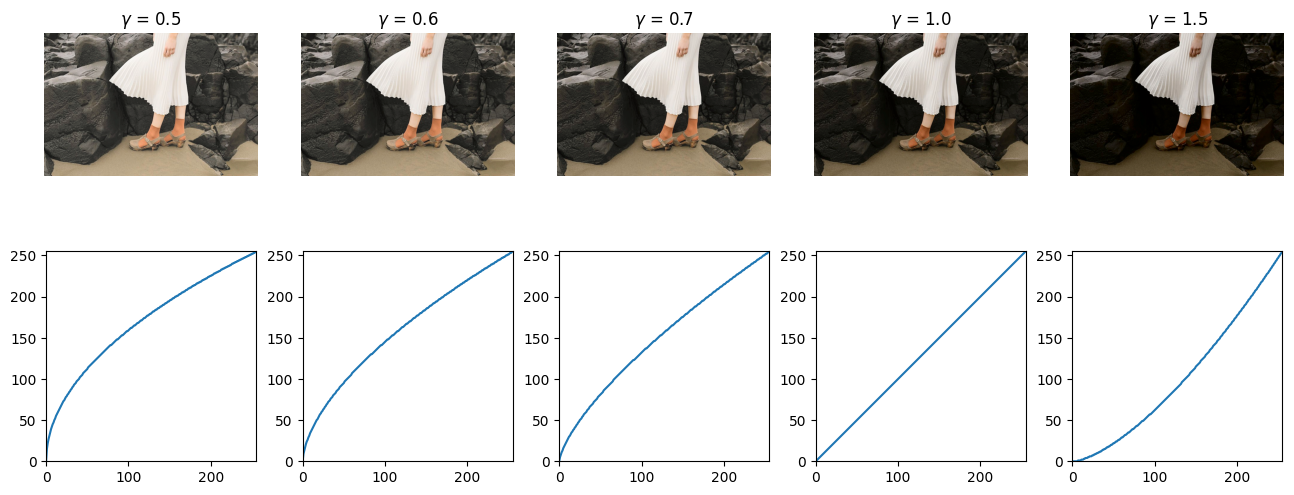

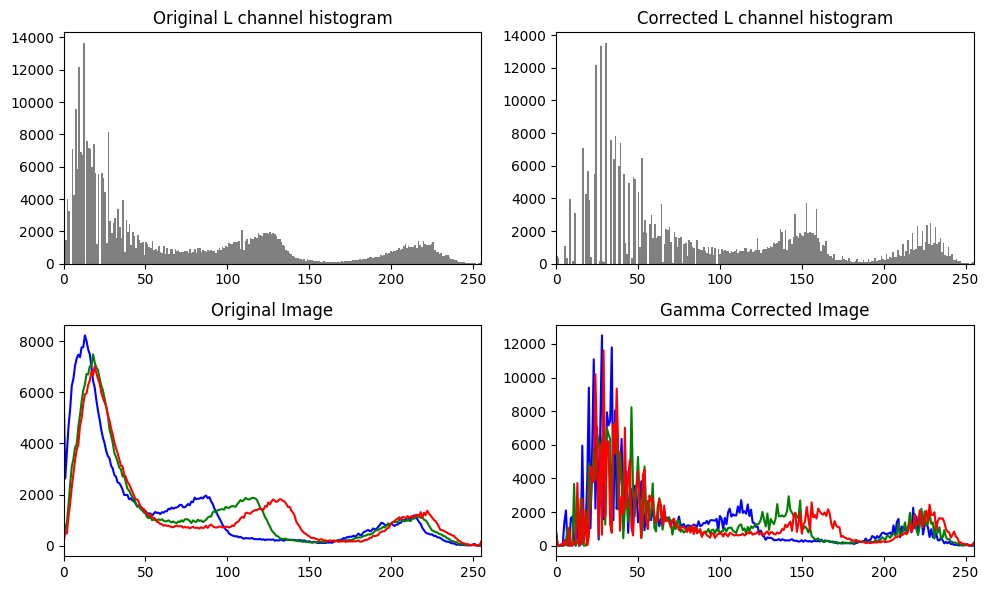

In [15]:
img = cv.imread("figures/fig3.png", cv.IMREAD_COLOR)

def gamma_lut(gamma):
    """ create a lookup table for gamma correction """
    return np.array([(i/255)**gamma * 255 for i in range(256)], dtype=np.uint8)

def gamma_correction(img, gamma_lut):
    """
    Apply gamma correction to an image using a lookup table.
    """
    lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    l = cv.LUT(l, gamma_lut)
    lab = cv.merge([l, a, b])
    return cv.cvtColor(lab, cv.COLOR_LAB2BGR)

gammas = [ 0.5, 0.6, 0.7, 1.0, 1.5]
fig, axes = plt.subplots(2, len(gammas), figsize=(16, 6))

for j, gamma in enumerate(gammas):
    lut = gamma_lut(gamma)
    out = gamma_correction(img, lut)
    axes[0,j].imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB)); axes[0,j].set_title(f'$\\gamma$ = {gamma}'); axes[0,j].axis('off')
    axes[1,j].plot(gamma_lut(gamma)); axes[1,j].set_xlim(0,255); axes[1,j].set_ylim(0,255); axes[1,j].set_aspect('equal')

#choosing gamma=0.7 for the final image

corrected = gamma_correction(img, gamma_lut(0.7))
L0 = cv.split(cv.cvtColor(img, cv.COLOR_BGR2LAB))[0]
L1 = cv.split(cv.cvtColor(corrected, cv.COLOR_BGR2LAB))[0]

fig, axes = plt.subplots(2,2, figsize=(10, 6))
axes[0,0].hist(L0.ravel(), bins=256, range=(0,255), color='gray')
axes[0,0].set_title('Original L channel histogram')
axes[0,1].hist(L1.ravel(), bins=256, range=(0,255), color='gray')
axes[0,1].set_title('Corrected L channel histogram')

for ax, img, title in [(axes[1,0], img, 'Original Image'), (axes[1,1], corrected, 'Gamma Corrected Image')]:
    for i, c in enumerate('bgr'):
        ax.plot(cv.calcHist([img], [i], None, [256], [0, 256]), color=c, label=f'{c.upper()} channel')
    ax.set_title(title)
    for ax in axes.ravel():
        ax.set_xlim(0, 255)
img_show()

---
## Question 4

Increasing the vibrance of a photograph is probably achieved by applying an intensity
transformation such as

$$
f(x) = \min\left(x + a \times 128\, e^{-\frac{(x-128)^2}{2\sigma^2}},\ 255\right),
$$

to the saturation plane, where $x$ is the input intensity, $a \in [0, 1]$ and $\sigma = 70$.

&nbsp;&nbsp;(a) Split the image shown in Fig. 4 into hue, saturation, and value planes.

&nbsp;&nbsp;(b) Apply the aforementioned intensity transformation to the saturation plane.

&nbsp;&nbsp;(c) Adjust $a$ to get a visually pleasing output. Report the value of $a$.

&nbsp;&nbsp;(d) Recombine the three planes.

&nbsp;&nbsp;(e) Display the original image, vibrance-enhanced image, and the intensity transformation.


<figure>
<img src="figures/fig4.png" width="320">
<figcaption><em>Figure 4: Image for enhancing the vibrance.</em></figcaption>
</figure>

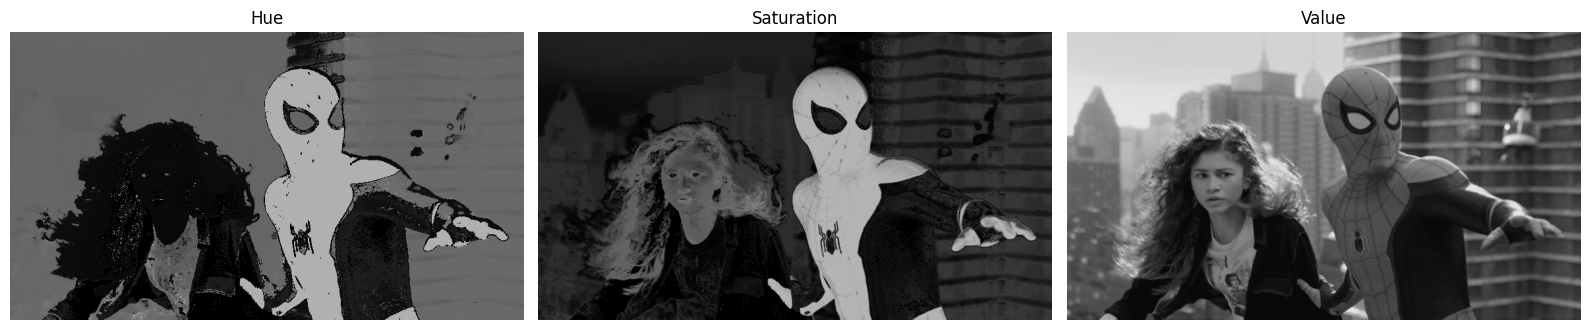

a=0.2: mean S 51 -> 63,  clipped at 255: 0.0%
a=0.4: mean S 51 -> 75,  clipped at 255: 0.0%
a=0.6: mean S 51 -> 87,  clipped at 255: 0.0%
a=0.8: mean S 51 -> 99,  clipped at 255: 8.5%
a=1.0: mean S 51 -> 109,  clipped at 255: 10.8%


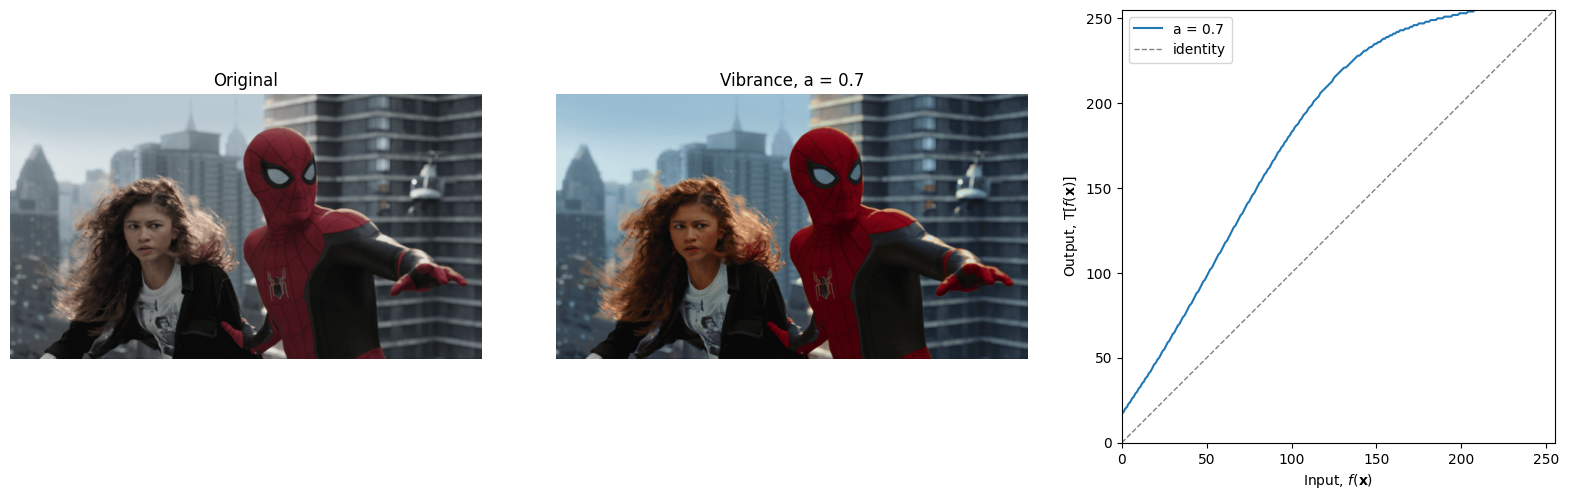

In [24]:
img = cv.imread("figures/fig4.png", cv.IMREAD_COLOR)
assert img is not None

SIGMA = 70

def vibrance_lut(a, sigma=SIGMA):
    """
    Create a lookup table for vibrance adjustment based on the given sigma value.
    """
    x = np.arange(256, dtype='float64')
    f = np.minimum(x + a*128*np.exp(-(x-128)**2/(2*sigma**2)), 255)
    return np.round(f).astype(np.uint8)

def enhance(img, a, sigma):
    """
    Enhance the vibrance of an image using the specified parameters.
    """
    h, s, v = cv.split(cv.cvtColor(img, cv.COLOR_BGR2HSV))
    s = cv.LUT(s, vibrance_lut(a, sigma))
    enhanced = cv.merge([h, s, v])
    return cv.cvtColor(enhanced, cv.COLOR_HSV2BGR)

h, s, v = cv.split(cv.cvtColor(img, cv.COLOR_BGR2HSV))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, plane, name in zip(axes, [h, s, v], ['Hue', 'Saturation', 'Value']):
    ax.imshow(plane, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout(); plt.show()

for a in [0.2, 0.4, 0.6, 0.8, 1.0]:
    s2 = cv.LUT(s, vibrance_lut(a))
    print(f'a={a}: mean S {s.mean():.0f} -> {s2.mean():.0f},  clipped at 255: {100*(s2==255).mean():.1f}%')

#picking a=0.7 for the final image

A = 0.7
out = enhance(img, A, SIGMA)

def img_draw2(img, vibrance_lut, A, out):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Vibrance, a = {A}'); axes[1].axis('off')
    axes[2].plot(vibrance_lut(A), label=f'a = {A}')
    axes[2].plot(np.arange(256), '--', color='gray', lw=1, label='identity')
    axes[2].set_xlim(0,255); axes[2].set_ylim(0,255); axes[2].set_aspect('equal')
    axes[2].set_xlabel(r'Input, $f(\mathbf{x})$'); axes[2].set_ylabel(r'Output, $\mathrm{T}[f(\mathbf{x})]$')
    axes[2].legend()

img_draw2(img, vibrance_lut, A, out)
plt.tight_layout(); plt.show()


---
## Question 5

Write a function of your own to carry out histogram equalization on the image shown in Fig. 5.
Show the histograms before and after equalization.


<figure>
<img src="figures/fig5.png" width="280">
<figcaption><em>Figure 5: Image for histogram equalization.</em></figcaption>
</figure>

---
## Question 6

In this question, we will apply histogram equalization only to the foreground of an image to
produce an image with a histogram equalized foreground.

&nbsp;&nbsp;(a) Open the image in Fig. 6, split it into hue, saturation, and values and display these planes in grayscale.

&nbsp;&nbsp;(b) Select the appropriate plane to threshold in extract the foreground mask. A mask is a binary image.

&nbsp;&nbsp;(c) Now obtain the foreground only using `cv.bitwise_and` and compute the histogram.

&nbsp;&nbsp;(d) Obtain the cumulative sum of the histogram using `np.cumsum`.

&nbsp;&nbsp;(e) Use the formulas in slides to histogram-equalize the foreground.

&nbsp;&nbsp;(f) Extract the background and add with the histogram equalized foreground.

Show the hue, saturation, and value plane, the mask, the original image, and the result with the
histogram-equalized foreground.


<figure>
<img src="figures/fig6.png" width="320">
<figcaption><em>Figure 6: Image for histogram equalizing the foreground.</em></figcaption>
</figure>

---
## Question 7

Filtering with the Sobel operator can compute the gradient. Consider the image shown in Fig. 7

&nbsp;&nbsp;(a) Using the existing `filter2D` to Sobel filter the image.

&nbsp;&nbsp;(b) Write your own code to Sobel filter the image.

&nbsp;&nbsp;(c) Using the property

$$
\begin{bmatrix}
1 & 0 & -1\\
2 & 0 & -2\\
1 & 0 & -1
\end{bmatrix}
=
\begin{bmatrix} 1\\ 2\\ 1 \end{bmatrix}
*
\begin{bmatrix} 1 & 0 & -1 \end{bmatrix},
$$

carry out Sobel filtering.


<figure>
<img src="figures/fig7.png" width="260">
<figcaption><em>Figure 7: Image for Sobel filtering.</em></figcaption>
</figure>

---
## Question 8

Write a program to zoom images by a given factor $s \in (0, 10]$. You must use a function to zoom
the image, which can handle

&nbsp;&nbsp;(a) nearest-neighbor, and

&nbsp;&nbsp;(b) bilinear interpolation.

I have included four images, two large originals, and there zoomed-out versions. Test you algorithm
by computing the normalized sum of squared difference (SSD) when you scale-up the given small images
by a factor of 4 by comparing with the original images.

---
## Question 9

Fig. 8<sup>2</sup> shows a flower image with both the foreground and background are in focus.

&nbsp;&nbsp;(a) Use `grabCut` to segment the image. Show the final segmentation mask, foreground image, and background image.

&nbsp;&nbsp;(b) Produce an enhanced image with a substantially blurred background. Display the original image alongside the enhanced image.

&nbsp;&nbsp;(c) Why is the background just beyond the edge of the flower quite dark in the enhanced image?

<sub><sup>2</sup> https://steemit.com/marguerite/@ctrl-alt-nwo/marguerite-daisy</sub>


<figure>
<img src="figures/fig8.png" width="260">
<figcaption><em>Figure 8: Image enhancing.</em></figcaption>
</figure>

---
## Question 10

Fig. 9 shows an image of Lake Minaret. The reuirement is to smoothen the image while keeping the
edges sharp.

&nbsp;&nbsp;(a) Use OpenCV's `bilateralFilter` to smoothen the image with a bilateral filter with $\sigma_s$ and $\sigma_r$ of your choice. Display the original, Gaussian blured image with a similar kernel, and bilateral filtered images side-by-side.

&nbsp;&nbsp;(b) Implement your own bilateral filter and compare the results with OpenCV's `bilateralFilter`. Display the original, Gaussian blured image with a similar kernel, and bilateral filtered images side-by-side. Use a suitable quantitative measure to compare the results.


<figure>
<img src="figures/fig9.png" width="240">
<figcaption><em>Figure 9: Image bilateral filtering.</em></figcaption>
</figure>

---
## GitHub Profile

You must include the link to your GitHub (or some other SVN) profile, so that I can see that you
have worked on this assignment over a reasonable duration. Therefore, make commits regularly.

## Submission

The report must be a PDF exported directly from your Jupyter Notebook. Reports created by manually
copying and pasting code snippets and images into another document will not be accepted. Upload a
report (maximum 10 pages) named `your_index_a01.pdf`. Include your index number and name within the
PDF as well. The report should contain the key parts of your code, representative image results,
comparisons of results, and a clear interpretation and discussion of the findings. The interpretation
of the results and the discussion are important components of the report. An extra-page penalty of
20 marks per page will be applied for pages beyond the 10-page limit.

**Grading policy:** This assignment contributes **5%** to the final grade. Since LLMs can be used to
generate code, you are required to include a link to your GitHub profile in the report. We will
review your commit history and timestamps to verify that the assignment was completed over a
reasonable period. Therefore, commit your work regularly throughout the assignment. For efficiency,
only the submitted PDF will be graded. However, your thorough and detailed understanding of the
assignment will be assessed in the final examination through questions about your implementation and
results.